# Run clustering in the tfh17 flow cytometry follow-up data
- related to Figure S9 B-D 

In [4]:
import scyan as sy
import os
import glob
import anndata
import re
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import scanpy as sc
#import flowsom as fs
import seaborn as sns
import scipy.stats as stats

In [5]:
print(sy.__version__)

1.6.2


In [6]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

In [7]:
sc.settings.n_jobs=30

In [8]:
# adata, table = sy.data.load("aml") # Automatic loading
# model = sy.sy(adata, table)
# model.fit()
# model.predict()

In [9]:
# define the working path
fcs_path='/home/workspace/private/ra-cohort-ide/ALTRA_revision/Tfh17_followup/flow/NonNaive fcs files/EC NonNaive fcs files/'
fig_path = '/home/workspace/private/ra-cohort-ide/ALTRA_revision/Tfh17_followup/flow/figure/'
output_path = '/home/workspace/private/ra-cohort-ide/ALTRA_revision/Tfh17_followup/flow/output_results/'
proj_name = 'ALTRA_TFH17_flow_followup_'

In [51]:
def scatter_with_correlation(df, x_col, y_col, title=None, save_path=None):
    """
    Plots a scatter plot with a regression line and displays the Pearson correlation coefficient (r) and p-value.

    Parameters:
        df (pd.DataFrame): DataFrame containing the data.
        x_col (str): Column name for the x-axis.
        y_col (str): Column name for the y-axis.
        title (str, optional): Title of the plot. Defaults to None.
        save_path (str, optional): Path to save the plot. Defaults to None (does not save).
    
    Returns:
        None
    """
    sns.set_style("ticks")
    # Compute Pearson correlation
    r, p = stats.spearmanr(df[x_col], df[y_col])

    # Create scatter plot with regression line
    plt.figure(figsize=(4, 4))
    ax = sns.regplot(x=x_col, y=y_col, data=df, scatter_kws={'s': 50}, line_kws={"color": "blue"})

    # Add correlation annotation
    plt.text(0.05, 0.8, f"r = {r:.2f}\np = {p:.3f}", transform=ax.transAxes, 
             fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

    # Labels and title
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(title if title else f"{x_col} vs {y_col}")

    # Save or show plot
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


# load data from FCS

In [7]:
# make a function to find files
def get_filepaths_with_glob(root_path: str, file_regex: str):
    return glob.glob(os.path.join(root_path, file_regex))

In [8]:
ec_files=get_filepaths_with_glob(fcs_path, '*.fcs')
ec_files[1:5]


['/home/workspace/private/ra-cohort-ide/ALTRA_revision/Tfh17_followup/flow/NonNaive fcs files/EC NonNaive fcs files/export_A10 PB00464-04_EC_nonCD4Tnve.fcs',
 '/home/workspace/private/ra-cohort-ide/ALTRA_revision/Tfh17_followup/flow/NonNaive fcs files/EC NonNaive fcs files/export_A11 PB00465-05_EC_nonCD4Tnve.fcs',
 '/home/workspace/private/ra-cohort-ide/ALTRA_revision/Tfh17_followup/flow/NonNaive fcs files/EC NonNaive fcs files/export_A12 PB00467-03_EC_nonCD4Tnve.fcs',
 '/home/workspace/private/ra-cohort-ide/ALTRA_revision/Tfh17_followup/flow/NonNaive fcs files/EC NonNaive fcs files/export_A2 PB00082-03_EC_nonCD4Tnve.fcs']

In [11]:
# load data
def read_one(file_path):
    adata = sy.read_fcs(file_path, marker_regex='^cd|^hla|tcr|ig|^ccr')
    adata.obs["sample"] = re.findall('PB\\d\\d\\d\\d\\d', file_path)[0].replace("PB", "KT")
    adata.obs["panel"] = re.findall( 'EC|IC', file_path)[0]
    adata.obs["pregated"] = 'CD4mem' 
    return adata
# load a test data
adata_test = read_one(ec_files[1])

In [12]:
print(f"Created anndata object with {adata_test.n_obs} cells and {adata_test.n_vars} markers.\n\n-> The markers names are: {', '.join(adata_test.var_names)}\n-> The non-marker names are: {', '.join(adata_test.obs.columns)}")


Created anndata object with 44393 cells and 21 markers.

-> The markers names are: CD69, CD8, CD25, CD28, CD4, CD38, TCR ab, CD127 (IL-7Ra), CD196 (CCR6), CD3, CD194 (CCR4), CD45RA, CD279 (PD-1), CD185 (CXCR5), CD14, CD278 (ICOS), CD183 (CXCR3), CD197 (CCR7), CD161 (NK1.1), CD19, TIGIT
-> The non-marker names are: FSC-A, FSC-H, SSC-A, SSC-B-A, SSC-B-H, SSC-H, Viability, Time, sample, panel, pregated


In [13]:
# load all data
adata_raw = anndata.concat([read_one(p) for p in ec_files], index_unique="-")

In [14]:
# Clean index function
def clean_index(index):
    index = index.strip()  # Remove leading/trailing spaces
    index = re.sub(r"[^a-zA-Z0-9 _]", "", index)  # Keep letters, numbers, spaces, (), _, and -
    index = re.sub(r"\s+", "_", index)  # Replace spaces with underscores
    return index.lower()  # Convert to lowercase

adata_raw.var['markers'] = adata_raw.var.index
adata_raw.var.index = adata_raw.var.index.map(clean_index)

In [15]:
adata_raw.var

,markers
cd69,CD69
cd8,CD8
cd25,CD25
cd28,CD28
cd4,CD4
cd38,CD38
tcr_ab,TCR ab
cd127_il7ra,CD127 (IL-7Ra)
cd196_ccr6,CD196 (CCR6)
cd3,CD3


In [46]:
# save the dataset
adata_raw.write_h5ad(output_path + proj_name + 'raw_flow_data.h5ad')

## preprocessing

In [16]:
adata = adata_raw.copy()

In [17]:
# save the raw data
adata.layers['raw'] = adata.X.copy()

In [18]:
adata.raw = adata.copy()

In [19]:
# logicl transform data
sy.preprocess.auto_logicle_transform(adata)


[WARNING] (scyan.preprocess) Auto logicle transformation failed for the following markers (logicle was used instead): cd4, tcr_ab, cd3.
It can happen when expressions are all positive or all negative.


In [20]:
sy.preprocess.scale(adata)

[INFO] (scyan.preprocess) Data will be centered and standardised. This is advised only when using spectral/flow data (if this is not your case, consider running 'asinh_transform' instead of 'auto_logicle_transform').


In [21]:
adata.var_names.sort_values()

Index(['cd127_il7ra', 'cd14', 'cd161_nk11', 'cd183_cxcr3', 'cd185_cxcr5',
       'cd19', 'cd194_ccr4', 'cd196_ccr6', 'cd197_ccr7', 'cd25', 'cd278_icos',
       'cd279_pd1', 'cd28', 'cd3', 'cd38', 'cd4', 'cd45ra', 'cd69', 'cd8',
       'tcr_ab', 'tigit'],
      dtype='object')

In [22]:
adata.var.index

Index(['cd69', 'cd8', 'cd25', 'cd28', 'cd4', 'cd38', 'tcr_ab', 'cd127_il7ra',
       'cd196_ccr6', 'cd3', 'cd194_ccr4', 'cd45ra', 'cd279_pd1', 'cd185_cxcr5',
       'cd14', 'cd278_icos', 'cd183_cxcr3', 'cd197_ccr7', 'cd161_nk11', 'cd19',
       'tigit'],
      dtype='object')

In [26]:
# select the marker for umap
markers_used = ['cd69', 'cd25', 'cd28', 'cd38', 'cd127_il7ra',
       'cd196_ccr6', 'cd194_ccr4', 'cd45ra', 'cd279_pd1', 'cd185_cxcr5',
        'cd278_icos', 'cd183_cxcr3', 'cd197_ccr7', 'cd161_nk11', 
       'tigit']

In [24]:
# run umap
sy.tools.umap(adata, markers=markers_used)

[INFO] (scyan.tools.representation) Fitting UMAP...
/home/workspace/environment/scyan/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


UMAP(min_dist=0.5, tqdm_kwds={'bar_format': '{desc}: {percentage:3.0f}%| {bar} {n_fmt}/{total_fmt} [{elapsed}]', 'desc': 'Epochs completed', 'disable': True})

In [26]:
adata.raw = adata

In [27]:
# subset the markers to only relevant 
adata = adata[:, markers_used]
adata

View of AnnData object with n_obs × n_vars = 1925917 × 15
    obs: 'FSC-A', 'FSC-H', 'SSC-A', 'SSC-B-A', 'SSC-B-H', 'SSC-H', 'Viability', 'Time', 'sample', 'panel', 'pregated'
    var: 'markers'
    uns: 'scyan_logicle', 'scyan_scaling_stds', 'scyan_scaling_means'
    obsm: 'X_umap'
    layers: 'raw'

In [28]:
sc.pp.neighbors(adata, n_neighbors=15, use_rep='X')

In [29]:
# Using the igraph implementation and a fixed number of iterations can be significantly faster, especially for larger datasets
sc.tl.leiden(adata, flavor="igraph", n_iterations=2)

In [30]:
sc.tl.leiden(adata, flavor="igraph", resolution=1.5, key_added='leiden_1_5', n_iterations=2)

In [31]:
sc.tl.leiden(adata, flavor="igraph", resolution=2, key_added='leiden_2', n_iterations=2)

/home/workspace/environment/scyan/lib/python3.9/site-packages/scyan/plot/_scanpy_plot/umap.py:884: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/scyan/lib/python3.9/site-packages/scyan/plot/_scanpy_plot/umap.py:884: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/scyan/lib/python3.9/site-packages/scyan/plot/_scanpy_plot/umap.py:884: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and 

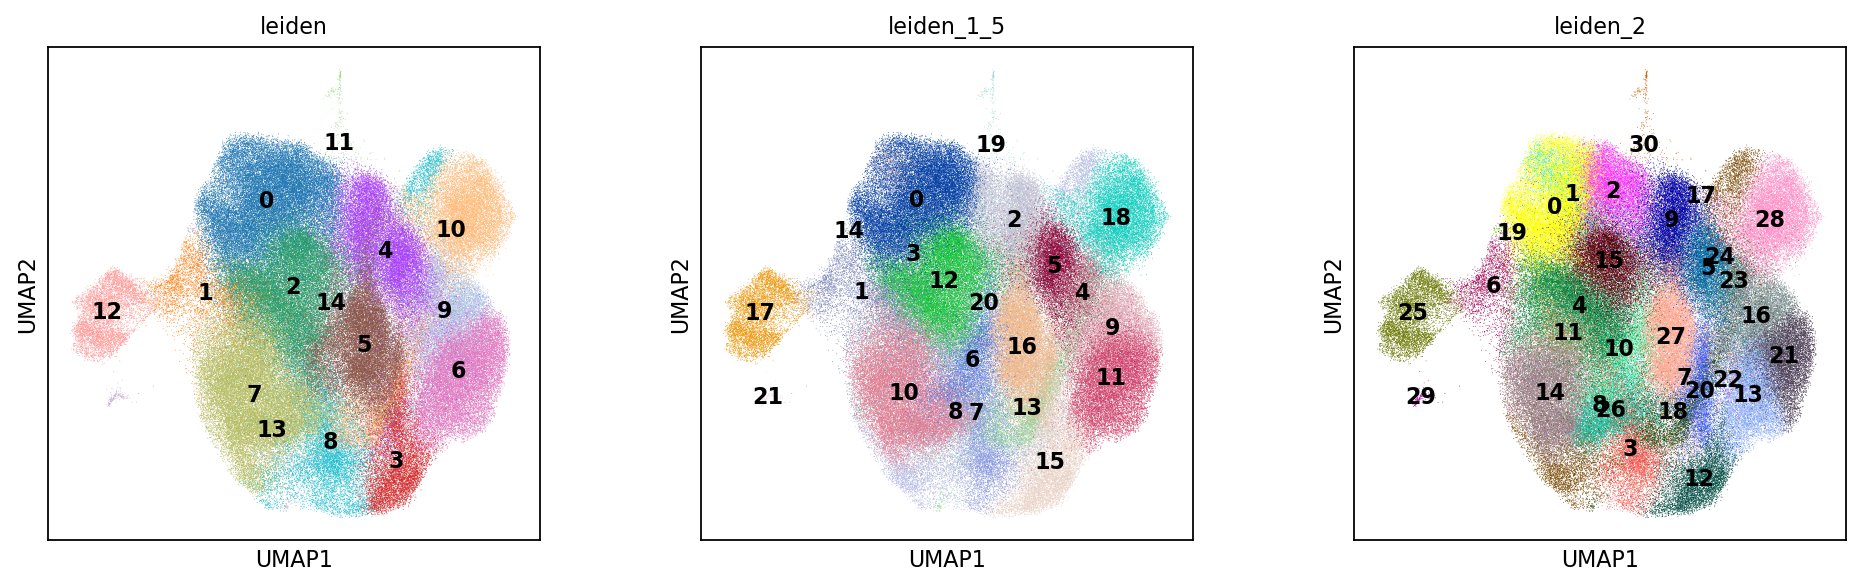

In [32]:
p1=sy.plot.umap(adata, color=['leiden', 'leiden_1_5', 'leiden_2'], show=False,
                legend_loc ='on data', return_fig=True)
p1.savefig(fig_path+ proj_name+'_leiden_umap.png')

### run flowsom clustering

In [ ]:
# run flowsom
adata = fs.flowsom_clustering(adata, cols_to_use=markers_used,
                                 n_clusters=20, xdim=10, ydim=10, seed=42)

2025-02-09 20:01:58.373 | DEBUG    | flowsom.main:__init__:84 - Reading input.
2025-02-09 20:01:58.376 | DEBUG    | flowsom.main:__init__:86 - Fitting model: clustering and metaclustering.


In [ ]:
adata.obs['FlowSOM_clusters'] = adata.obs['FlowSOM_clusters'].astype('str').astype("category")
adata.obs['FlowSOM_metaclusters'] = adata.obs['FlowSOM_metaclusters'].astype('str').astype("category")

### plot fig S9B

/home/workspace/environment/scyan/lib/python3.9/site-packages/scyan/plot/_scanpy_plot/umap.py:884: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


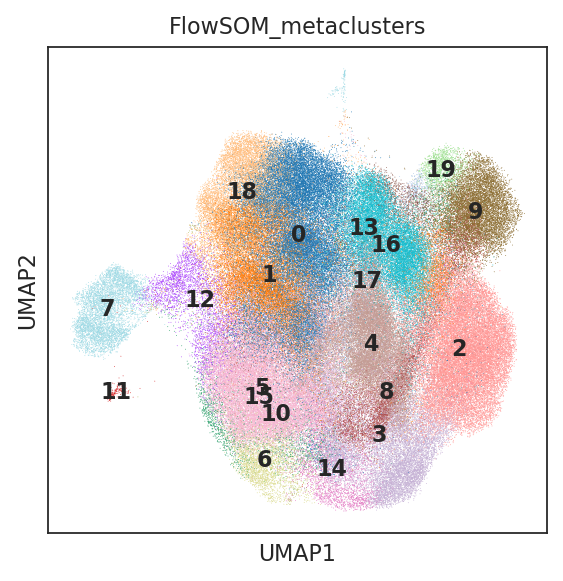

In [28]:
p1=sy.plot.umap(adata, color=[ 'FlowSOM_metaclusters'], show=False,
                legend_loc ='on data', return_fig=True)
p1.savefig(fig_path+ proj_name+'FlowSOM_umap.pdf')

/home/workspace/environment/scyan/lib/python3.9/site-packages/scyan/plot/_scanpy_plot/umap.py:884: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


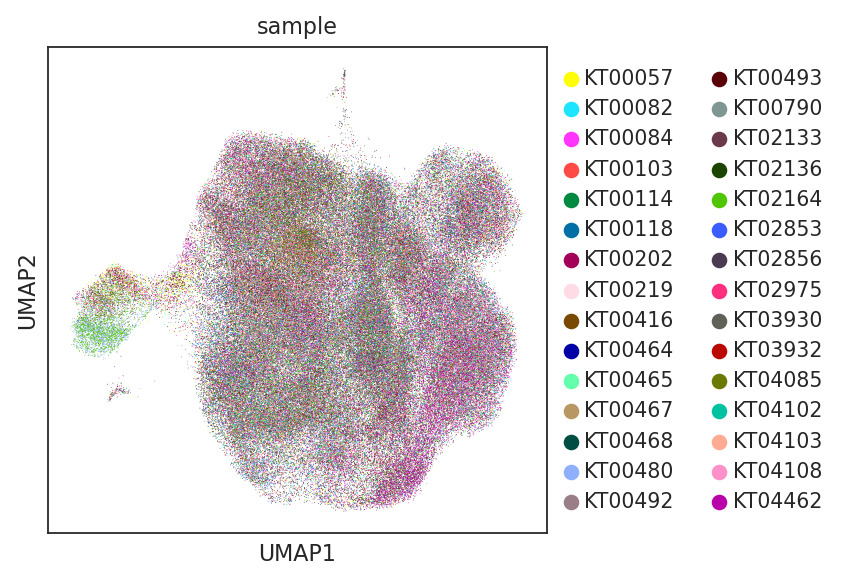

In [54]:
p1=sy.plot.umap(adata, color=['sample'], show=False, return_fig=True)
p1.savefig(fig_path+ proj_name+'_sample_umap.png', bbox_inches='tight')

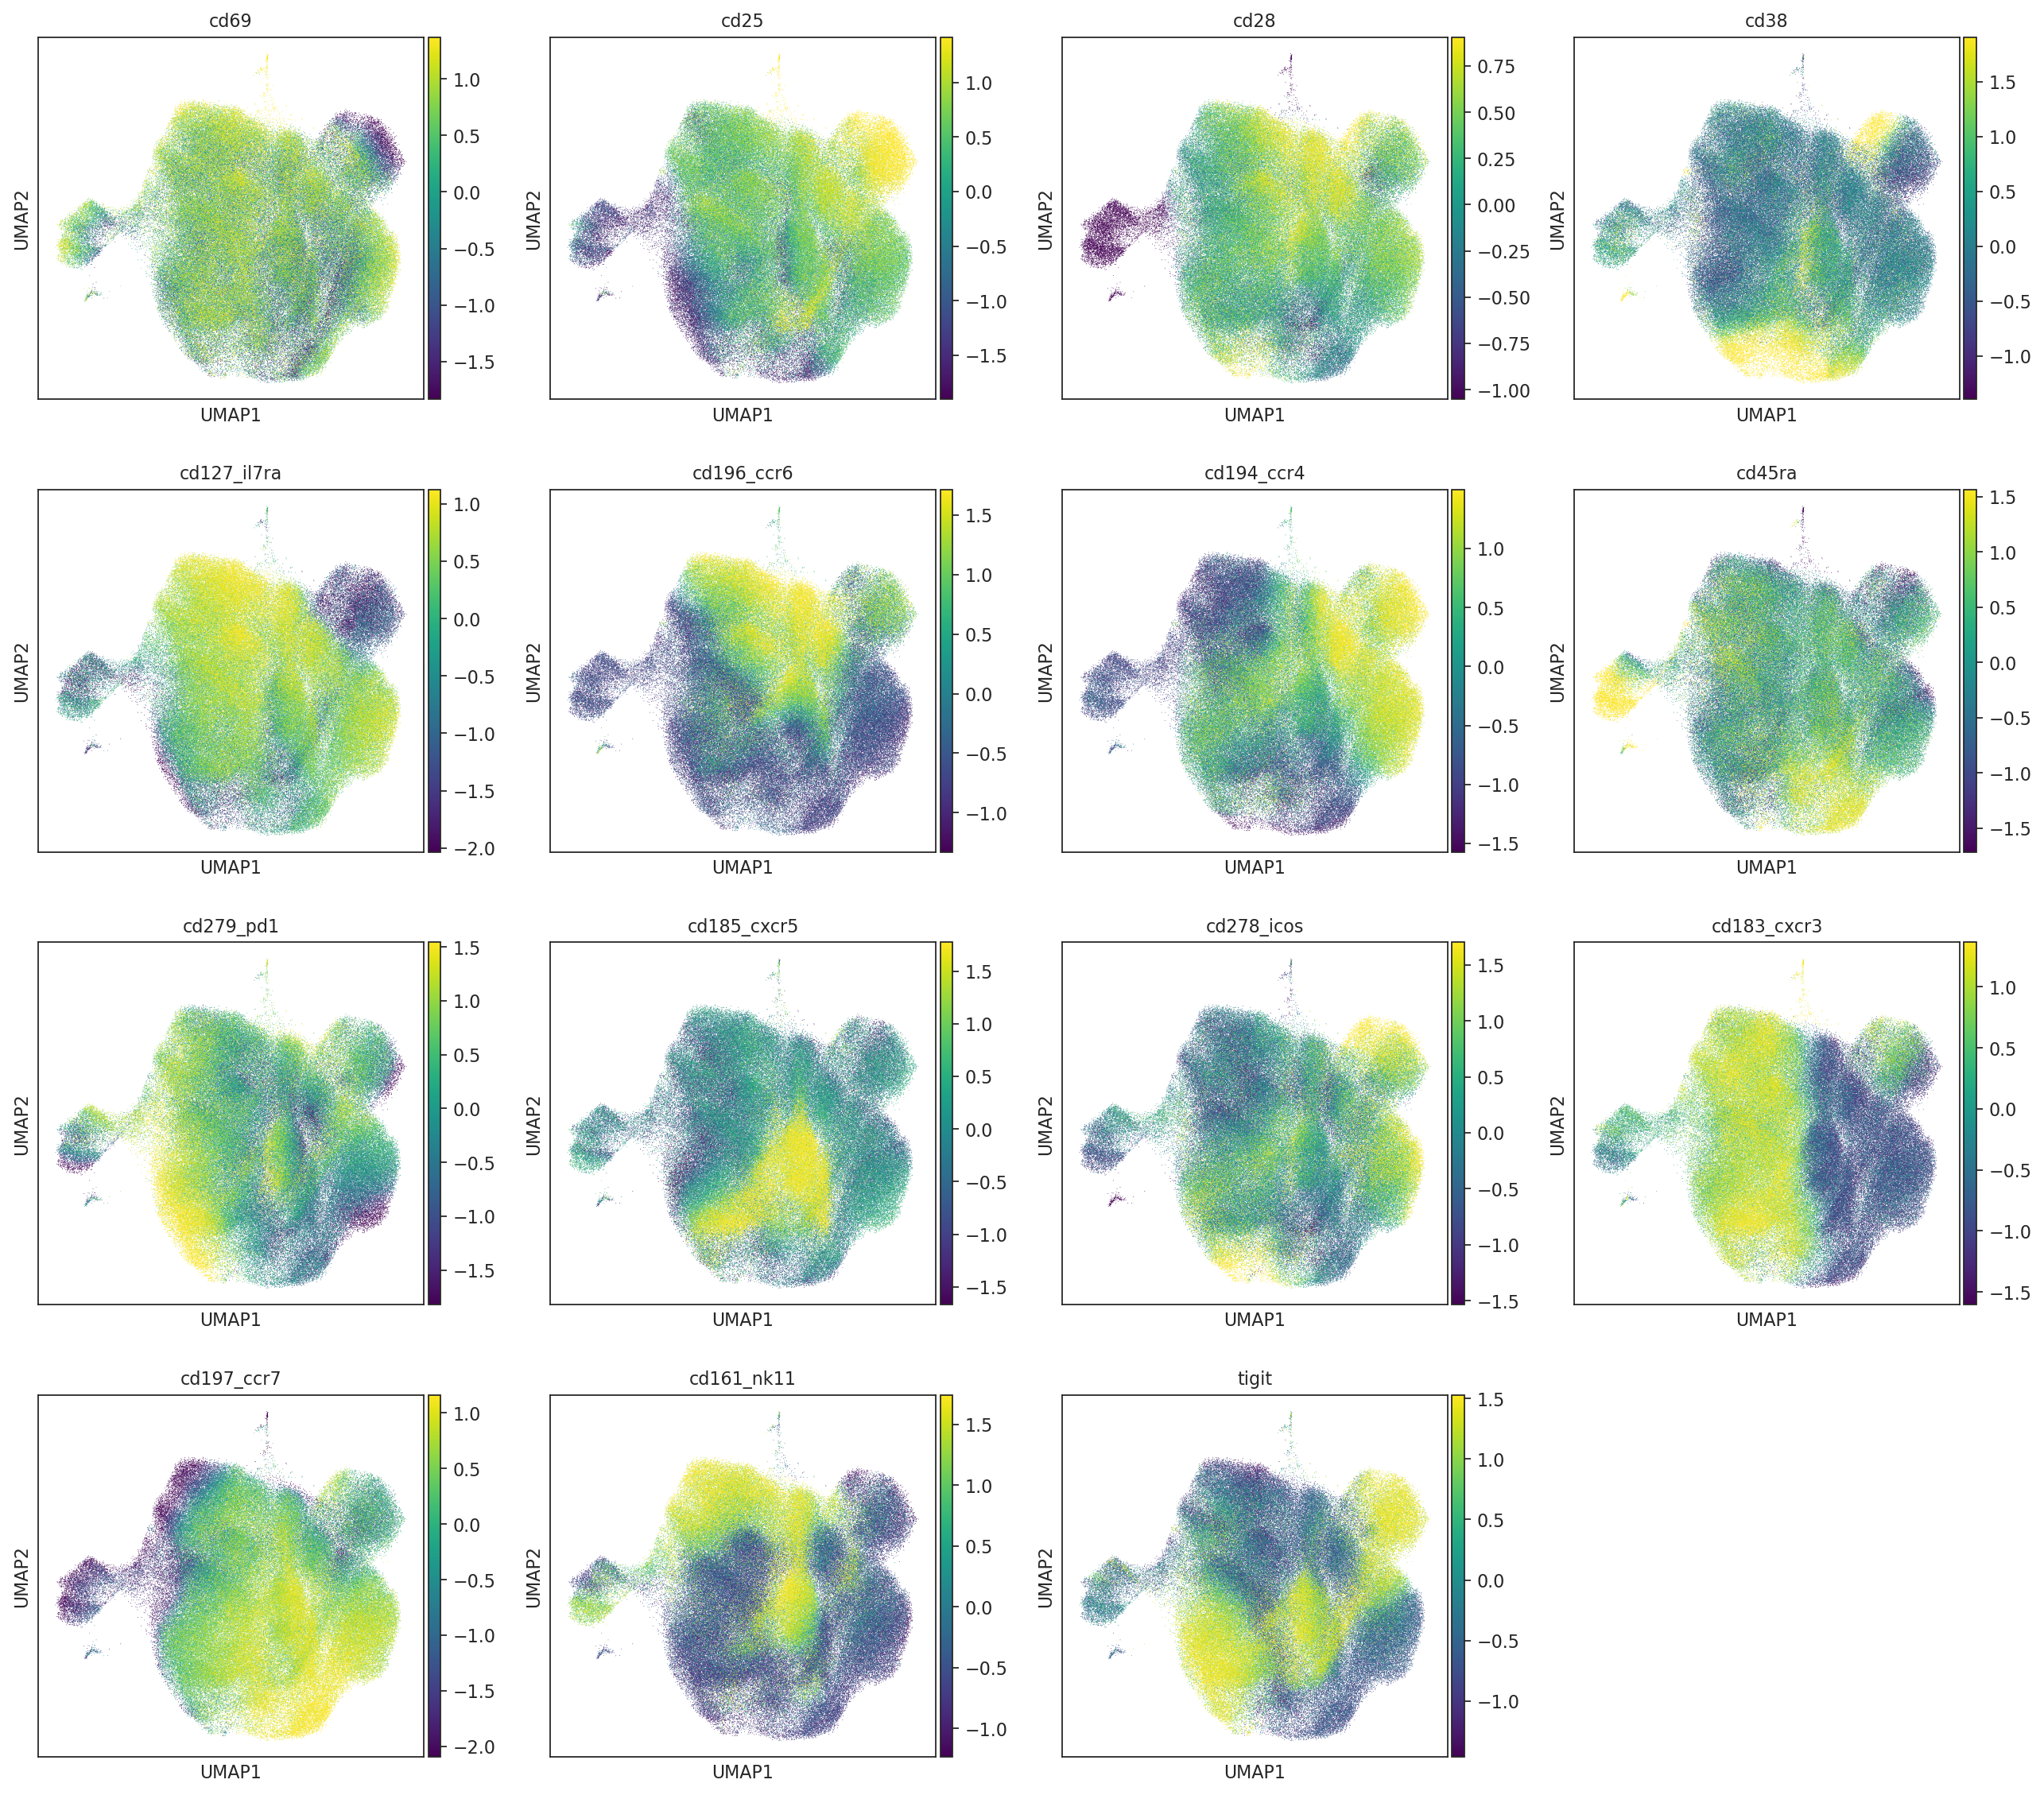

In [60]:
p1=sy.plot.umap(adata, color=markers_used, color_map = 'viridis',
             ncols=4, show=False, return_fig=True)
p1.savefig(fig_path+ proj_name+'_expression_umap.pdf')

### plot fig S9C

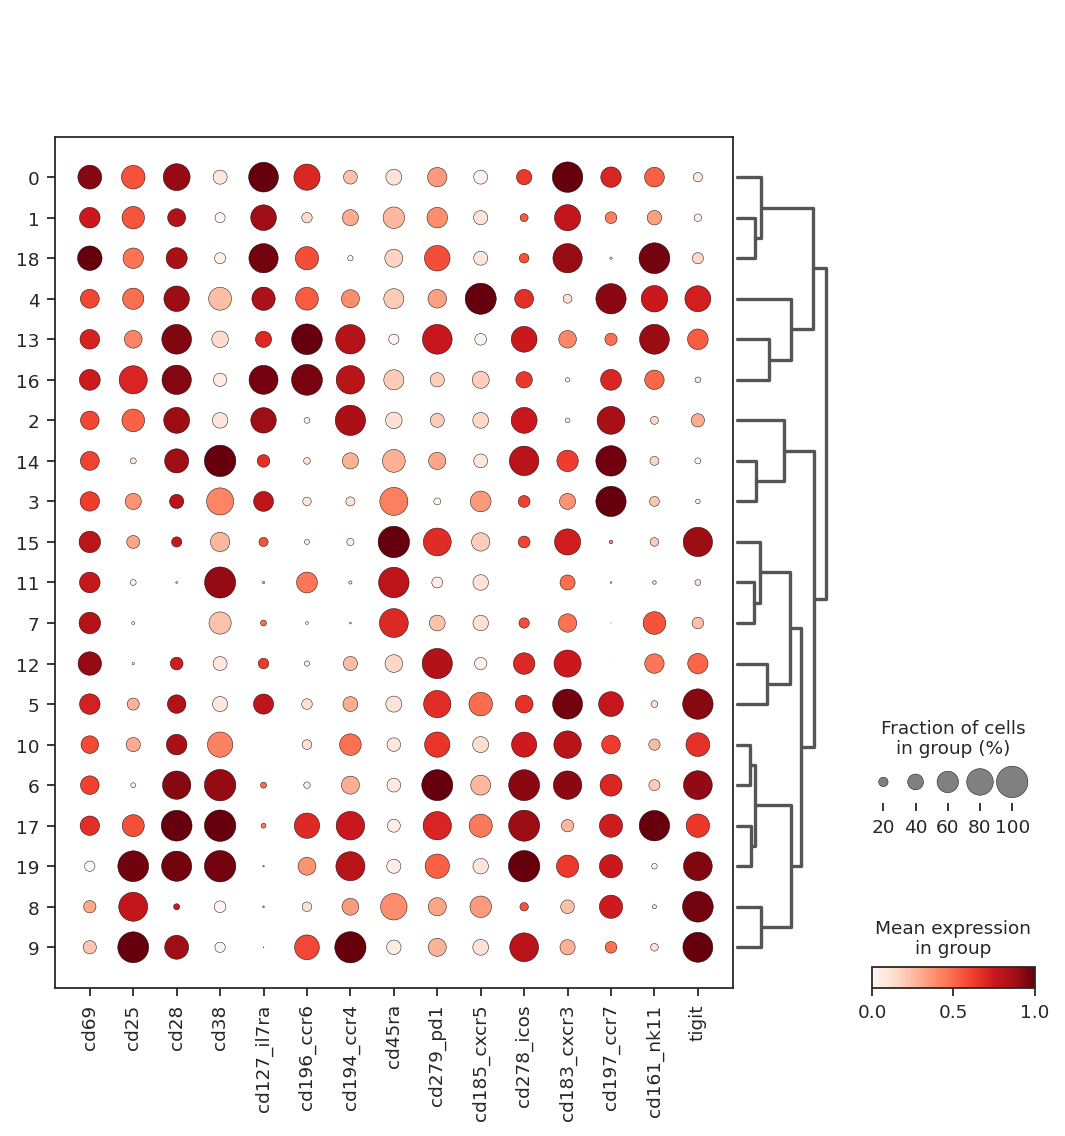

In [27]:
sc.tl.dendrogram(adata, 'FlowSOM_metaclusters')
dp =sc.pl.dotplot(adata, markers_used, groupby="FlowSOM_metaclusters", 
    standard_scale="var", dendrogram=True, return_fig=True)
dp.savefig(fig_path+ proj_name+'_flowsom_expression_dotplot.pdf')

In [65]:
# Obtain cluster-specific differentially expressed genes
sc.tl.rank_genes_groups(adata, groupby="FlowSOM_metaclusters", method="wilcoxon")

/home/workspace/environment/scyan/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/workspace/environment/scyan/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/workspace/environment/scyan/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/workspace/environment/scyan/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/workspace/environment/scyan/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name,

In [ ]:
# save the dataset
adata.write_h5ad(output_path + proj_name + 'flow_data.h5ad')

## examine the frequency correlation

In [40]:
# load the dataset
adata = sc.read_h5ad(output_path + proj_name + 'flow_data.h5ad')

In [11]:
# load all cluster freq
scrna_freq = pd.read_csv('/home/workspace/private/ra-cohort-ide/ALTRA_revision/Tfh17_followup/CD4T_mem_certpro_Frq_clr_res_0_4_freq.csv')
scrna_freq.head()

,Unnamed: 0,sample.sampleKitGuid,BMI,days_to_conversion,ageAtDraw,subject.biologicalSex,subject.subjectGuid,bmi_conv,age_conv,Status_Long,Status_Xsec,Age2023,anti_ccp3,anti_ccp3_finalCombined,anti_ccp31,clusters,frequency_live,clr
0,1,KT00052,24.657159,-714.0,56,Female,CU1009,25.648918,58.0,pre,at_risk,60,88.0,88.0,74.0,cluster0,0.104238,0.984863
1,2,KT00052,24.657159,-714.0,56,Female,CU1009,25.648918,58.0,pre,at_risk,60,88.0,88.0,74.0,cluster1,0.070733,0.597098
2,3,KT00052,24.657159,-714.0,56,Female,CU1009,25.648918,58.0,pre,at_risk,60,88.0,88.0,74.0,cluster2,0.096220,0.904821
3,4,KT00052,24.657159,-714.0,56,Female,CU1009,25.648918,58.0,pre,at_risk,60,88.0,88.0,74.0,cluster3,0.068729,0.568348
4,5,KT00052,24.657159,-714.0,56,Female,CU1009,25.648918,58.0,pre,at_risk,60,88.0,88.0,74.0,cluster4,0.076460,0.674958


In [14]:
# load C3 frequency
c3_freq = pd.read_csv('/home/workspace/private/ra-cohort-ide/ALTRA_revision/C3_high_low_sample_selection_01062025.csv')
c3_freq.head()

,sample.sampleKitGuid,BMI,days_to_conversion,ageAtDraw,subject.biologicalSex,subject.subjectGuid,bmi_conv,age_conv,Status_Long,Status_Xsec,Age2023,anti_ccp3,anti_ccp3_finalCombined,anti_ccp31,clusters,Freq_CD4mem,clr,max_ccp3,ccp3_cat,timepoint
0,KT00057,21.126531,-615,21,Female,CU1003,23.143062,23,pre,at_risk,25,262,262,262,cluster3,0.057254,0.270449,904,high,low
1,KT00493,22.493064,-127,23,Female,CU1003,23.143062,23,pre,NaN,25,262,687,262,cluster3,0.129265,1.180249,904,high,high
2,KT00082,25.987896,-540,43,Female,CU1007,26.194977,44,pre,NaN,46,262,2901,262,cluster3,0.048311,0.186855,2901,high,low
3,KT00492,25.948341,-163,44,Female,CU1007,26.194977,44,pre,NaN,46,262,1622,262,cluster3,0.094851,0.990996,2901,high,high
4,KT00219,23.699600,-498,57,Female,CU1009,25.648918,58,pre,NaN,60,91,91,149,cluster3,0.056488,0.525759,97,high,low


In [15]:
c3_freq = c3_freq.loc[c3_freq['clusters']=='cluster3', 
    ['sample.sampleKitGuid', 'subject.subjectGuid',
     'Freq_CD4mem', 'timepoint']].rename(columns={'Freq_CD4mem':'C3_freq'})
c3_freq.head()

,sample.sampleKitGuid,subject.subjectGuid,C3_freq,timepoint
0,KT00057,CU1003,0.057254,low
1,KT00493,CU1003,0.129265,high
2,KT00082,CU1007,0.048311,low
3,KT00492,CU1007,0.094851,high
4,KT00219,CU1009,0.056488,low


### examine frequency from flowsom clusters correlation with scRNA clusters

In [47]:
# metaclusters 
fm_freq_table = sy.tools.cell_type_ratios(adata, groupby='sample', 
                                          normalize=True, key='FlowSOM_metaclusters',
                                          among=None)
fm_freq_table.to_csv(output_path + proj_name+ 'FlowSOM_metaclusters_frequency.csv')


/home/workspace/environment/scyan/lib/python3.9/site-packages/scyan/tools/biomarkers.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = adata.obs.groupby(groupby)


In [30]:
fm_freq_table = pd.read_csv(output_path + proj_name+ 'FlowSOM_metaclusters_frequency.csv').rename(columns={'sample':'sample.sampleKitGuid'})

In [31]:
fm_freq_table.columns = fm_freq_table.columns.str.replace(' ratio', '_flow')

In [32]:
fm_freq_table.head()

,sample.sampleKitGuid,0_flow,1_flow,10_flow,11_flow,12_flow,13_flow,14_flow,15_flow,16_flow,...,18_flow,19_flow,2_flow,3_flow,4_flow,5_flow,6_flow,7_flow,8_flow,9_flow
0,KT00057,0.174419,0.058636,0.012958,0.000617,0.054585,0.013765,0.021154,0.002611,0.073397,...,0.057528,0.009683,0.102225,0.061895,0.060740,0.112825,0.017942,0.067875,0.022799,0.068856
1,KT00082,0.178566,0.112262,0.011494,0.000887,0.006827,0.015371,0.014368,0.005516,0.112262,...,0.040056,0.010453,0.111568,0.073961,0.100729,0.083719,0.023143,0.001138,0.029468,0.058243
2,KT00084,0.183217,0.056472,0.007249,0.001100,0.019852,0.011925,0.017318,0.002210,0.098553,...,0.063161,0.007907,0.153080,0.082060,0.091736,0.098327,0.015835,0.005167,0.017878,0.060096
3,KT00103,0.158027,0.066708,0.019103,0.001519,0.016274,0.021173,0.018305,0.005982,0.117390,...,0.063765,0.005317,0.063461,0.051346,0.124891,0.149596,0.032262,0.000684,0.039782,0.038681
4,KT00114,0.166911,0.066892,0.020964,0.002201,0.013322,0.016942,0.019592,0.005655,0.110288,...,0.063106,0.010719,0.069519,0.057759,0.125858,0.124225,0.038782,0.001017,0.033600,0.044366


In [34]:
# merge the two frequency table
fm_freq_table = fm_freq_table.merge(
        c3_freq, on='sample.sampleKitGuid', how='inner'
                                          ).set_index('sample.sampleKitGuid')

In [35]:
fm_freq_table.head()

,0_flow,1_flow,10_flow,11_flow,12_flow,13_flow,14_flow,15_flow,16_flow,17_flow,...,3_flow,4_flow,5_flow,6_flow,7_flow,8_flow,9_flow,subject.subjectGuid,C3_freq,timepoint
sample.sampleKitGuid,,,,,,,,,,,,,,,,,,,,,
KT00057,0.174419,0.058636,0.012958,0.000617,0.054585,0.013765,0.021154,0.002611,0.073397,0.005490,...,0.061895,0.060740,0.112825,0.017942,0.067875,0.022799,0.068856,CU1003,0.057254,low
KT00082,0.178566,0.112262,0.011494,0.000887,0.006827,0.015371,0.014368,0.005516,0.112262,0.009971,...,0.073961,0.100729,0.083719,0.023143,0.001138,0.029468,0.058243,CU1007,0.048311,low
KT00084,0.183217,0.056472,0.007249,0.001100,0.019852,0.011925,0.017318,0.002210,0.098553,0.006856,...,0.082060,0.091736,0.098327,0.015835,0.005167,0.017878,0.060096,CU1029,0.080045,high
KT00103,0.158027,0.066708,0.019103,0.001519,0.016274,0.021173,0.018305,0.005982,0.117390,0.005735,...,0.051346,0.124891,0.149596,0.032262,0.000684,0.039782,0.038681,SD1003,0.117718,low
KT00114,0.166911,0.066892,0.020964,0.002201,0.013322,0.016942,0.019592,0.005655,0.110288,0.008282,...,0.057759,0.125858,0.124225,0.038782,0.001017,0.033600,0.044366,SD1003,0.139821,high


In [43]:
fm_freq_table.to_csv(output_path + proj_name+ 'FlowSOM_metaclusters_frequency_withC3.csv')


In [38]:
fm_freq_table.drop(columns=['timepoint', 'subject.subjectGuid']).corr(
    method='spearman').loc['C3_freq'].sort_values(ascending=False)

C3_freq    1.000000
6_flow     0.381090
17_flow    0.263626
13_flow    0.260512
14_flow    0.258287
10_flow    0.183092
11_flow    0.181758
16_flow    0.175083
19_flow    0.170634
5_flow     0.155506
4_flow     0.143493
15_flow    0.110122
8_flow     0.094549
12_flow    0.073192
0_flow    -0.001112
7_flow    -0.009566
18_flow   -0.022469
9_flow    -0.073192
1_flow    -0.095884
3_flow    -0.119466
2_flow    -0.203115
Name: C3_freq, dtype: float64

In [63]:
from scipy.stats import spearmanr

def r_pvalues(df):
    cols = pd.DataFrame(columns=df.columns)
    p = cols.transpose().join(cols, how='outer')
    for r in df.columns:
        for c in df.columns:
            tmp = df[df[r].notnull() & df[c].notnull()]
            p[r][c] = round(spearmanr(tmp[r], tmp[c])[1], 4)
    return p

spearman_p = r_pvalues(fm_freq_table.drop(columns=['timepoint', 'subject.subjectGuid']))
spearman_p = spearman_p.loc[spearman_p.index!='C3_freq', ['C3_freq']]''

/tmp/ipykernel_780/2685469308.py:9: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  p[r][c] = round(spearmanr(tmp[r], tmp[c])[1], 4)


### plot Fig S9D

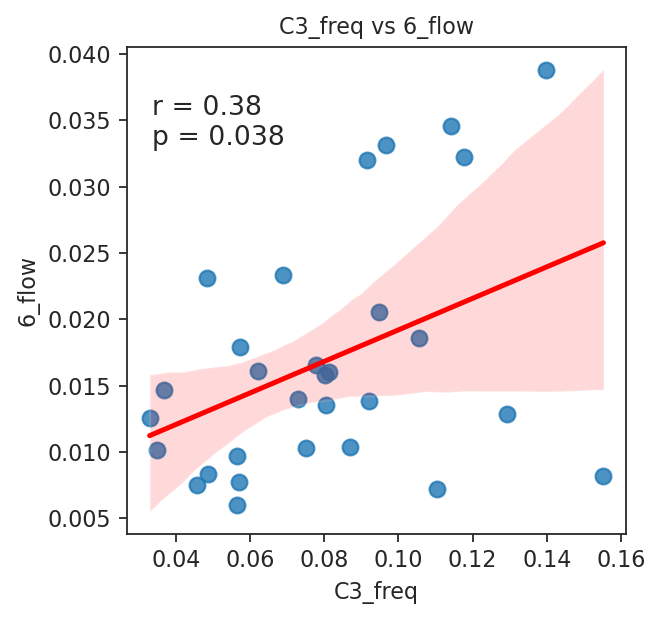

In [42]:
scatter_with_correlation(fm_freq_table, x_col='C3_freq', y_col='6_flow',
                         save_path = fig_path + proj_name + 'flowsomC6_scRNAc3_corplot.pdf')